<a href="https://colab.research.google.com/github/Vikrant25122004/Stock-Price-Prediction-Using-LSTM/blob/main/Stock_Price_Prediction_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stock Price Prediction using LSTM

This project aims to develop a predictive model for stock prices using Long Short-Term Memory (LSTM) neural networks, a type of recurrent neural network (RNN) particularly well-suited for time series forecasting. The ability to forecast stock prices can be invaluable for investors, traders, and financial analysts in making informed decisions.

### Project Objectives:
1.  **Data Acquisition**: Obtain historical stock price data (Open, Close, High, Low, Volume) for a specified stock from the National Stock Exchange (NSE).
2.  **Data Preprocessing**: Clean and prepare the acquired data, which includes handling missing values, converting data types, and scaling numerical features to improve model performance.
3.  **Exploratory Data Analysis (EDA)**: Analyze historical trends, patterns, and statistical properties of the stock data through visualizations to gain insights into its behavior.
4.  **Model Development**: Construct and train an LSTM model using a portion of the historical data to learn the complex temporal dependencies within the stock prices.
5.  **Model Evaluation**: Assess the model's predictive accuracy by comparing its forecasts against actual stock prices using appropriate metrics such as Mean Squared Error (MSE) and Mean Absolute Error (MAE).
6.  **Visualization of Results**: Plot predicted stock prices against actual prices to visually demonstrate the model's performance and identify areas for improvement.

### Methodology:
*   **LSTM Networks**: LSTMs are chosen due to their effectiveness in handling sequential data and capturing long-term dependencies, which are crucial for accurate time series forecasting like stock prices.
*   **Feature Scaling**: Stock prices often vary significantly. Scaling the data (e.g., using `StandardScaler`) ensures that the neural network converges faster and performs better.
*   **Time Series Preparation**: The historical data is transformed into a supervised learning problem by creating sequences of past observations (e.g., 100 days) to predict future values.

### Expected Outcomes:
By the end of this project, we expect to have a robust LSTM model capable of predicting future stock prices with reasonable accuracy. The visualizations will provide clear insights into the model's strengths and limitations, serving as a foundation for further optimization and real-world application.

### Installing Libraries
This code cell uses the `!pip install` command to install necessary Python libraries for the project:
*   `nselib`: This library is used to fetch historical stock data from the National Stock Exchange (NSE) in India.
*   `pandas-market-calendars`: This library provides functionalities to work with market calendars, which can be useful for handling trading days, holidays, etc., though its specific use might be elaborated later in the notebook. Installing these libraries ensures that all required dependencies are met before proceeding with data acquisition and processing.

In [1]:
# installing nse libraries
!pip install nselib
!pip install pandas-market-calendars


INFO: pip is looking at multiple versions of nselib to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas_market_calendars-5.1.3-py3-none-any.whl.metadata (9.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.5/127.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


### Data Acquisition
This code cell is responsible for acquiring the historical stock price data. It performs the following steps:
1.  **Imports**: Imports `capital_market` from `nselib` to access NSE data, `pandas` for data manipulation, and `datetime` for date handling.
2.  **User Input**: Prompts the user to enter the stock symbol (e.g., 'RELIANCE') and the start and end dates for the analysis. This makes the data acquisition process interactive.
3.  **Data Fetching**: Calls `capital_market.price_volume_and_deliverable_position_data` to fetch historical stock data based on the user's input.
4.  **DataFrame Conversion**: Converts the fetched data into a pandas DataFrame named `df`, which is a standard structure for tabular data in Python, making it easy to work with in subsequent steps.

In [42]:
## taking stock data from exchange
from nselib import capital_market
import pandas as pd
from datetime import datetime

import pandas_market_calendars as mcal
### input
stock_input = input("tell me which stock would you like to predict ")
### taking dates
st_dateinput = input("tell me starting date from you would like to analyse in ""dd-mm--yy format example 08-08-2025"" ")
end_dateinput = input("tell me ending date from you would like to analyse ""dd-mm--yy format example 08-08-2025"" ")
### getting data
stock = capital_market.price_volume_and_deliverable_position_data(stock_input, from_date=st_dateinput,to_date=end_dateinput)
### converting to dataframe
df = pd.DataFrame(stock)


tell me which stock would you like to predict RELIANCE
tell me starting date from you would like to analyse in dd-mm--yy format example 08-08-2025 01-01-2019
tell me ending date from you would like to analyse dd-mm--yy format example 08-08-2025 01-12-2025


### Displaying Raw Data
This simple code cell `df` displays the entire DataFrame that was loaded in the previous step. This is a crucial step for initial data inspection, allowing the user to see the raw structure, column names, and a sample of the data, which helps in understanding its format and identifying any immediate issues before detailed preprocessing.

In [43]:
#printing data
df

,Symbol,Series,Date,PrevClose,OpenPrice,HighPrice,LowPrice,LastPrice,ClosePrice,AveragePrice,TotalTradedQuantity,TurnoverInRs,No.ofTrades,DeliverableQty,%DlyQttoTradedQty,"ï»¿""Symbol"""
0,NaN,EQ,01-Jan-2019,"1,121.25","1,125.25","1,127.30","1,110.10","1,120.50","1,121.00","1,119.01",4455850,4.986129e+09,76742,1306898.0,29.33,RELIANCE
1,NaN,EQ,02-Jan-2019,"1,121.00","1,114.50","1,127.00","1,101.00","1,104.35","1,106.40","1,113.42",7144970,7.955342e+09,147850,2543832.0,35.60,RELIANCE
2,NaN,EQ,03-Jan-2019,"1,106.40","1,107.50","1,114.60","1,090.10","1,090.30","1,092.75","1,101.37",7446457,8.201292e+09,231404,2883339.0,38.72,RELIANCE
3,NaN,EQ,04-Jan-2019,"1,092.75","1,097.40","1,104.45","1,081.10","1,099.60","1,098.65","1,093.06",8465141,9.252947e+09,189220,3496807.0,41.31,RELIANCE
4,NaN,EQ,07-Jan-2019,"1,098.65","1,107.00","1,118.45","1,101.00","1,104.90","1,104.75","1,110.32",5513559,6.121831e+09,112082,2138247.0,38.78,RELIANCE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,NaN,EQ,25-Nov-2025,"1,535.90","1,535.90","1,559.60","1,525.10","1,540.00","1,539.70","1,546.34",15033482,2.324691e+10,299805,7863116.0,52.30,RELIANCE
1733,NaN,EQ,26-Nov-2025,"1,539.70","1,542.30","1,571.60","1,540.50","1,569.60","1,569.90","1,562.98",14054299,2.196659e+10,285274,8561296.0,60.92,RELIANCE
1734,NaN,EQ,27-Nov-2025,"1,569.90","1,575.00","1,575.50","1,556.00","1,564.80","1,563.40","1,563.68",9794643,1.531570e+10,278929,5655438.0,57.74,RELIANCE
1735,NaN,EQ,28-Nov-2025,"1,563.40","1,568.00","1,581.30","1,563.00","1,569.00","1,567.50","1,571.94",8959508,1.408384e+10,229373,4892138.0,54.60,RELIANCE


### Data Preprocessing and Scaling
This block focuses on preparing the raw data for model training:
1.  **Imports**: Imports `matplotlib.pyplot` for plotting, `MinMaxScaler` and `StandardScaler` from `sklearn.preprocessing` for data scaling, and `numpy` for numerical operations.
2.  **String Cleaning**: Removes commas from the 'ClosePrice' and 'OpenPrice' columns, as these are typically present in large number strings and can interfere with numerical conversion.
3.  **Data Extraction**: Extracts 'ClosePrice' and 'OpenPrice' columns into separate variables.
4.  **Type Conversion**: Converts the `close_data` and `open_data` to float data types, which is essential for numerical computations.
5.  **Reshaping**: Reshapes the data using `.values.reshape(-1, 1)` to convert it into a 2D array, a format often required by scikit-learn scalers.
6.  **Feature Scaling**: Initializes `StandardScaler` and applies `fit_transform` to both `close_data` and `open_data`. Scaling is vital for neural networks like LSTMs, as it normalizes the input features, preventing larger values from dominating the learning process and helping the model converge faster and more effectively.

In [52]:
## Exploratory date analytics

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

df['ClosePrice'] = df['ClosePrice'].str.replace(",","")
df['OpenPrice'] = df['OpenPrice'].str.replace(",","")

close_data = df['ClosePrice']
open_data = df['OpenPrice']
open_data = open_data.astype(float)
close_data = close_data.astype(float)


std_scaler = StandardScaler()
close_data = close_data.values.reshape(-1, 1)
open_data = open_data.values.reshape(-1, 1)
scaled_data = std_scaler.fit_transform(close_data)
scaled_data_open = std_scaler.fit_transform(open_data)



### Plotting Scaled Prices
This cell visualizes the scaled 'Open Price' and 'Close Price' data:
*   It creates a plot using `matplotlib.pyplot` with a specified figure size.
*   It plots both `scaled_data_open` and `scaled_data` (scaled close prices) on the same graph.
*   `plt.legend()` adds a legend to distinguish between the 'Open Price' and 'Close Price' lines.
This visualization allows for a quick visual inspection of the stock's open and close price trends after scaling, confirming the preprocessing step and providing an initial understanding of the data's behavior.

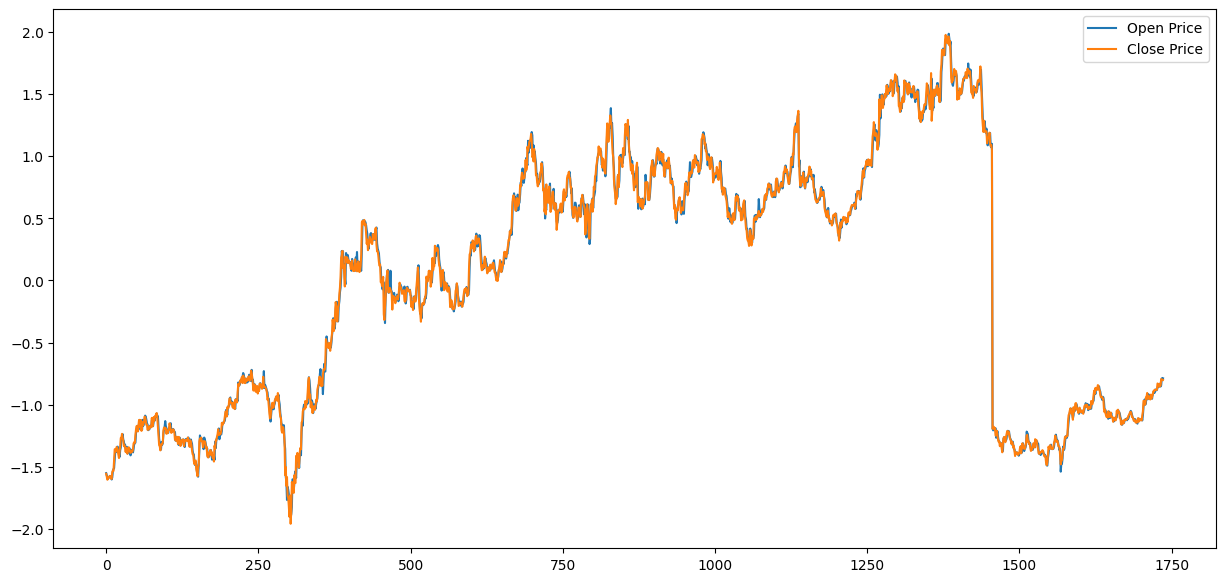

In [45]:
# plotting price of stock
plt.figure(14, figsize=(15, 7))
plt.plot(scaled_data_open, label='Open Price')

plt.plot(scaled_data, label='Close Price')
plt.legend()


### Creating Time Series Sequences
This code block prepares the scaled data into sequences suitable for LSTM training. LSTMs require input in a time-series format, where the model learns from a sequence of past observations to predict the next value. Here's how it works:
*   **Sliding Window**: It iterates through the `scaled_data` and creates sequences of 100 previous data points (`X`) to predict the current data point (`y`). This is known as a sliding window or look-back period.
*   **`x_train_close`, `y_train_close`**: These lists store the input sequences (100 previous close prices) and the target values (the next close price) for training the close price prediction model.
*   **`x_train_open`, `y_train_open`**: Similarly, these lists are created for the open price prediction model, although the current implementation uses `scaled_data` (close prices) for both open and close training data. This might be an oversight if the intention was to train an open price model using `scaled_data_open` as input.
*   **Shape Print**: The `print(y_train_close[0].shape)` and `print(y_train_open[0].shape)` statements verify the shape of a single target value, which should be `(1,)` for predicting a single price.

In [46]:

#splitting data and making timestamps
from re import X
x_train_close = []
y_train_close = []
i = 100
while(i<len(scaled_data)):
  X = scaled_data[i-100:i]
  x_train_close.append(X)
  y_train_close.append(scaled_data[i])
  i = i+1

print(y_train_close[0].shape)
x_train_open = []
y_train_open = []
i = 100
while(i<len(scaled_data)):
  X = scaled_data[i-100:i]
  x_train_open.append(X)
  y_train_open.append(scaled_data[i])
  i = i+1

print(y_train_open[0].shape)

(1,)
(1,)


### Building and Training LSTM Models
This is the core model development cell, where two LSTM models are built and trained:
1.  **Imports**: Imports `Sequential`, `LSTM`, `Dense`, `Dropout` from `tensorflow.keras.models` and `Adam` from `tensorflow.keras.optimizers` for building the neural networks, and `numpy` for array manipulation.
2.  **Array Conversion**: Converts the `x_train` and `y_train` lists (created in the previous cell) into NumPy arrays. This is necessary for TensorFlow/Keras models.
3.  **Model 1 (Close Price Prediction)**:
    *   A `Sequential` model is defined.
    *   **`LSTM(64, return_sequences=True, input_shape=(...))`**: The first LSTM layer with 64 units. `return_sequences=True` means it will output a sequence, which is necessary for stacking another LSTM layer.
    *   **`Dropout(0.2)`**: A dropout layer is added to prevent overfitting by randomly setting 20% of the input units to 0 at each update during training.
    *   **`LSTM(32)`**: A second LSTM layer with 32 units. Since it's the last LSTM layer before a Dense layer, `return_sequences` is `False` by default, meaning it outputs a single vector.
    *   **`Dense(16, activation='relu')`**: A dense (fully connected) hidden layer with 16 neurons and ReLU activation.
    *   **`Dense(1, activation='linear')`**: The output layer with 1 neuron and linear activation, suitable for regression tasks like price prediction.
    *   **Compilation**: The model is compiled with the Adam optimizer (learning rate 1e-3), Mean Squared Error (`mse`) as the loss function, and Mean Absolute Error (`mae`) as a metric.
    *   **Training**: The model is trained for 50 epochs with a batch size of 32 using `x_train_close_np` and `y_train_close_np`.
4.  **Model 2 (Open Price Prediction)**:
    *   A second `Sequential` model (`model1`) is defined with a similar architecture to `model`.
    *   **Training (Potential Issue)**: Crucially, `model.fit(x_train_open_np, y_train_open_np, epochs=50, batch_size=32)` is called. This line trains `model` (the first model defined) again using the open price data, overwriting the training it received for close prices. If the intent was to train a separate `model1` for open prices, the line should have been `model1.fit(...)`.

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Convert x_train and y_train from lists of arrays to single NumPy arrays
x_train_close_np = np.array(x_train_close)
y_train_close_np = np.array(y_train_close)
x_train_open_np = np.array(x_train_open)
y_train_open_np = np.array(y_train_open)

# Example: predicting next-step price (regression)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(x_train_close_np.shape[1], x_train_close_np.shape[2])),  # uses tanh/sigmoid internally
    Dropout(0.2),
    LSTM(32),   # internal activations remain tanh/sigmoid by default
    Dense(16, activation='relu'),   # hidden dense: relu or leakyrelu
    Dense(1, activation='linear')   # linear for regression output (raw price or log-price)
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.fit(x_train_close_np, y_train_close_np, epochs=50, batch_size=32)


model1 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(x_train_open_np.shape[1], x_train_open_np.shape[2])),  # uses tanh/sigmoid internally
    Dropout(0.2),
    LSTM(32),   # internal activations remain tanh/sigmoid by default
    Dense(16, activation='relu'),   # hidden dense: relu or leakyrelu
    Dense(1, activation='linear')   # linear for regression output (raw price or log-price)
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.fit(x_train_open_np, y_train_open_np, epochs=50, batch_size=32)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.3802 - mae: 0.4474
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0373 - mae: 0.1156
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0382 - mae: 0.1118
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0242 - mae: 0.0962
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0179 - mae: 0.0916
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0277 - mae: 0.0974
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0198 - mae: 0.0863
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0127 - mae: 0.0805
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0121 - mae: 0.0775
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0140 - mae: 0.0802
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0159 - mae: 0.0773
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0170 - mae: 0.0769
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/s

### Plotting Prediction Results
This cell evaluates the trained models and visualizes their predictions against the actual stock prices:
1.  **Prediction**: `model.predict(x_train_close_np[1000:])` generates predictions for the close prices using a portion of the training data (from index 1000 onwards). Similarly, `model1.predict(x_train_open_np[1000:])` generates predictions for the open prices.
2.  **Inverse Scaling**: `std_scaler.inverse_transform(result)` and `std_scaler.inverse_transform(result1)` revert the scaled predictions back to their original price scale. This is necessary to compare them with actual prices.
3.  **Inverse Scaling for Actual Values**: `std_scaler.inverse_transform(y_train_close_np)` also inverse transforms the actual close price values to their original scale for comparison.
4.  **Plotting**:
    *   `plt.plot(result, color='red', label='close Predicted Price')` plots the predicted close prices.
    *   `plt.plot(y_train_np[1000:], color='blue', label='Actual Price')` plots the actual close prices.
5.  **Labels and Legend**: Adds a title, x-axis label, y-axis label, and a legend to make the plot understandable.
6.  **Display**: `plt.show()` displays the generated plot. This visualization allows for a direct comparison between the model's predictions and the actual stock movements, helping to assess the model's performance visually.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


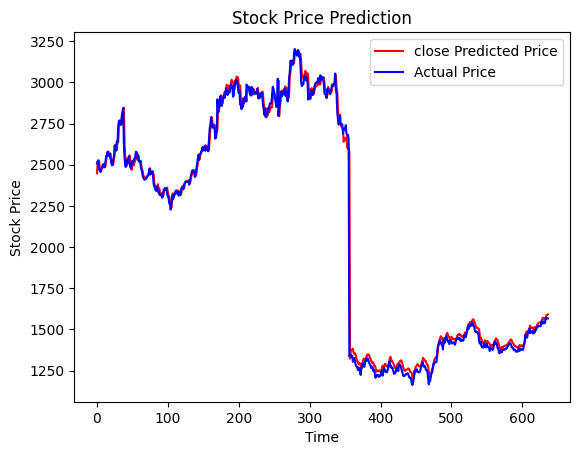

In [51]:
## ploting accuracy by plotting predicted and actual values
result = model.predict(x_train_close_np[1000:])
result1 = model1.predict(x_train_open_np[1000:])
result = std_scaler.inverse_transform(result)
result1 = std_scaler.inverse_transform(result1)
y_train_np = std_scaler.inverse_transform(y_train_close_np)
plt.plot(result, color='red', label='close Predicted Price')

plt.plot(y_train_np[1000:], color='blue', label='Actual Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()
